# Project 1 – Exercise 1: Enzyme Kinetics (Michaelis-Menten)
**Batch reactor design and operation**

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 12

## Part (a) – Mass Balances

The elementary reactions are:
$$S + E \xrightarrow{k_1} ES, \quad ES \xrightarrow{k_{-1}} S + E, \quad ES \xrightarrow{k_{cat}} P + E$$

Mass balances (in a constant-volume batch reactor, so moles ↔ concentrations):

$$\frac{d[S]}{dt} = -k_1[S][E] + k_{-1}[ES]$$
$$\frac{d[E]}{dt} = -k_1[S][E] + k_{-1}[ES] + k_{cat}[ES]$$
$$\frac{d[ES]}{dt} = k_1[S][E] - k_{-1}[ES] - k_{cat}[ES]$$
$$\frac{d[P]}{dt} = k_{cat}[ES]$$

Note the conservation: $[E] + [ES] = [E_0]$ (total enzyme is conserved).

## Part (b) – Full ODE System

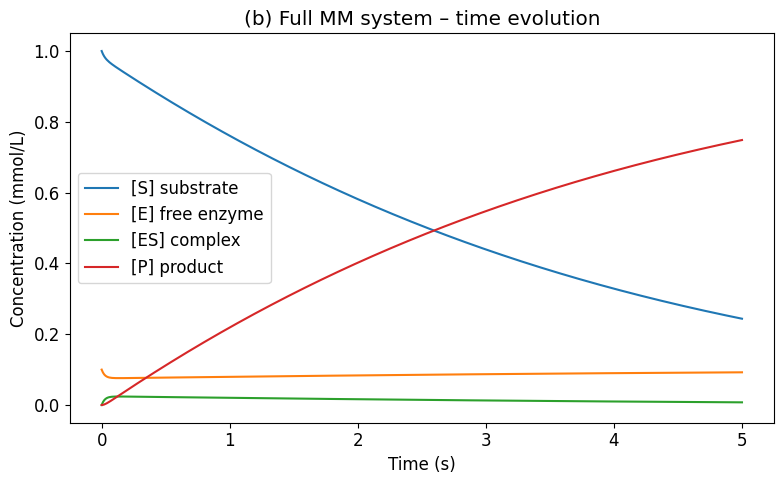


Interpretation:
  - [S] decreases as substrate is consumed.
  - [ES] rises quickly then decays as substrate is depleted.
  - [E] is transiently sequestered in ES, then recovers.
  - [P] rises monotonically, mirroring [S] depletion.


In [4]:
# ─── Parameters ───────────────────────────────────────────────────────────────
k1   = 10.0   # L/(mmol·s)
km1  = 20.0   # 1/s  (k_{-1})
kcat = 10.0   # 1/s

# Initial concentrations  [mmol/L]
S0  = 1.0
E0  = 0.1
P0  = 0.0
ES0 = 0.0

t_span = (0, 5)       # seconds
t_eval = np.linspace(0, 5, 500)

# ─── ODE system ───────────────────────────────────────────────────────────────
def ode_full(t, y, k1, km1, kcat):
    S, E, ES, P = y
    dS  = -k1*S*E + km1*ES
    dE  = -k1*S*E + km1*ES + kcat*ES
    dES =  k1*S*E - km1*ES - kcat*ES
    dP  =  kcat*ES
    return [dS, dE, dES, dP]

y0_full = [S0, E0, ES0, P0]
sol_full = solve_ivp(ode_full, t_span, y0_full, args=(k1, km1, kcat),
                     t_eval=t_eval, method='Radau', rtol=1e-8, atol=1e-10)

S_f, E_f, ES_f, P_f = sol_full.y

# ─── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots()
ax.plot(sol_full.t, S_f,  label='[S] substrate')
ax.plot(sol_full.t, E_f,  label='[E] free enzyme')
ax.plot(sol_full.t, ES_f, label='[ES] complex')
ax.plot(sol_full.t, P_f,  label='[P] product')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Concentration (mmol/L)')
ax.set_title('(b) Full MM system – time evolution')
ax.legend()
plt.tight_layout()
plt.savefig('b_full_ode.png', dpi=150)
plt.show()
print('\nInterpretation:')
print('  - [S] decreases as substrate is consumed.')
print('  - [ES] rises quickly then decays as substrate is depleted.')
print('  - [E] is transiently sequestered in ES, then recovers.')
print('  - [P] rises monotonically, mirroring [S] depletion.')

## Part (c) – Quasi-Steady State Approximation (QSSA)

Setting $d[ES]/dt = 0$:
$$k_1[S][E] = (k_{-1} + k_{cat})[ES]$$

Using enzyme conservation $[E] = [E_0] - [ES]$:
$$k_1[S]([E_0] - [ES]) = (k_{-1}+k_{cat})[ES]$$
$$[ES] = \frac{[E_0][S]}{K_M + [S]}, \quad K_M = \frac{k_{-1}+k_{cat}}{k_1}$$

The Michaelis constant for our parameters:
$$K_M = \frac{20+10}{10} = 3 \text{ mmol/L}$$

In [5]:
KM = (km1 + kcat) / k1
print(f'K_M = {KM:.3f} mmol/L')

K_M = 3.000 mmol/L


## Part (d) – QSSA ODE System

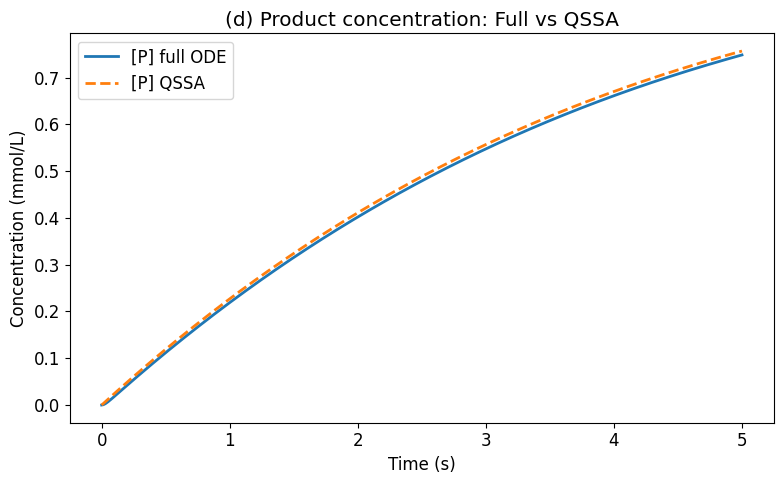

The QSSA slightly overestimates [P] at very early times (before [ES] reaches
its pseudo-steady state), but converges quickly to the full solution.


In [6]:
# Under QSSA: [ES] = E0*S / (KM + S)
# Only two ODEs needed: dS/dt and dP/dt

def ode_qssa(t, y, kcat, KM, E0):
    S, P = y
    ES = E0 * S / (KM + S)
    dS = -kcat * ES
    dP =  kcat * ES
    return [dS, dP]

y0_qssa = [S0, P0]
sol_qssa = solve_ivp(ode_qssa, t_span, y0_qssa, args=(kcat, KM, E0),
                     t_eval=t_eval, method='Radau', rtol=1e-8, atol=1e-10)

S_q, P_q = sol_qssa.y

# ─── Compare P from full vs QSSA ──────────────────────────────────────────────
fig, ax = plt.subplots()
ax.plot(sol_full.t, P_f,  label='[P] full ODE', lw=2)
ax.plot(sol_qssa.t, P_q,  label='[P] QSSA', lw=2, linestyle='--')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Concentration (mmol/L)')
ax.set_title('(d) Product concentration: Full vs QSSA')
ax.legend()
plt.tight_layout()
plt.savefig('d_qssa_comparison.png', dpi=150)
plt.show()
print('The QSSA slightly overestimates [P] at very early times (before [ES] reaches')
print('its pseudo-steady state), but converges quickly to the full solution.')

## Part (e) – Initial Rate v(t=0) as a function of parameters

The MM equation: $v = \frac{v_{max}[S]}{K_M + [S]}$ where $v_{max} = k_{cat}[E_0]$.

At $t=0$, $[S] = S_0$:
$$v_0 = \frac{k_{cat}[E_0]S_0}{K_M + S_0}$$

QSSA validity requires $[E_0] \ll [S_0]$, so we scan $[E_0]$ in $[0.001, 0.1]$ mmol/L.

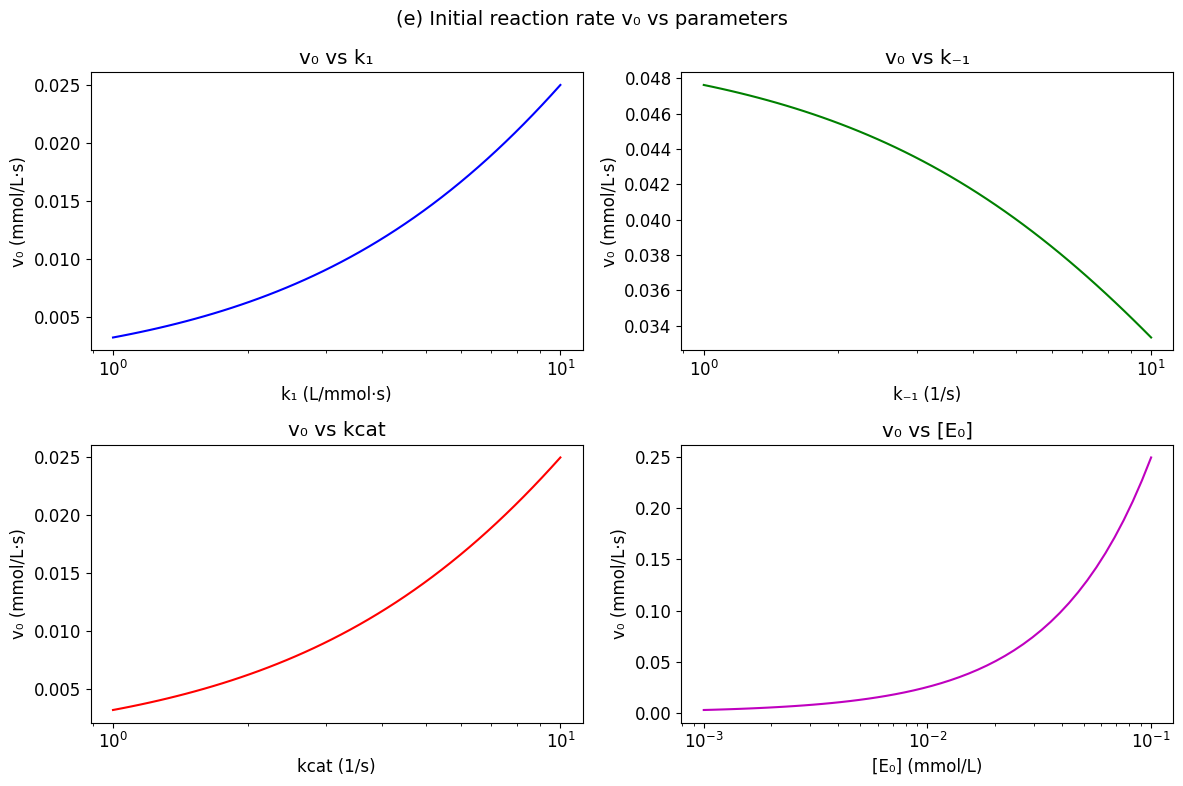

Higher k1 → lower KM → higher v0 (more complex formation).
Higher km1 → higher KM → lower v0 (less complex stability).
Higher kcat → higher vmax and lower KM → higher v0 in both ways.
[E0] scales v0 linearly (vmax = kcat * E0).


In [7]:
# ─── Ranges ───────────────────────────────────────────────────────────────────
k1_range   = np.logspace(0, 1, 50)    # 1–10  L/(mmol·s)
km1_range  = np.logspace(0, 1, 50)    # 1–10  1/s
kcat_range = np.logspace(0, 1, 50)    # 1–10  1/s
E0_range   = np.logspace(-3, np.log10(0.1), 50)  # 0.001–0.1 mmol/L (QSSA valid)

def v0(k1, km1, kcat, E0, S0=1.0):
    KM = (km1 + kcat) / k1
    vmax = kcat * E0
    return vmax * S0 / (KM + S0)

# Reference parameters
k1r, km1r, kcatr, E0r = 10, 20, 10, 0.01

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].semilogx(k1_range,   [v0(k, km1r, kcatr, E0r) for k in k1_range], 'b')
axes[0,0].set_xlabel('k₁ (L/mmol·s)'); axes[0,0].set_ylabel('v₀ (mmol/L·s)')
axes[0,0].set_title('v₀ vs k₁')

axes[0,1].semilogx(km1_range,  [v0(k1r, k, kcatr, E0r) for k in km1_range], 'g')
axes[0,1].set_xlabel('k₋₁ (1/s)'); axes[0,1].set_ylabel('v₀ (mmol/L·s)')
axes[0,1].set_title('v₀ vs k₋₁')

axes[1,0].semilogx(kcat_range, [v0(k1r, km1r, k, E0r) for k in kcat_range], 'r')
axes[1,0].set_xlabel('kcat (1/s)'); axes[1,0].set_ylabel('v₀ (mmol/L·s)')
axes[1,0].set_title('v₀ vs kcat')

axes[1,1].semilogx(E0_range,   [v0(k1r, km1r, kcatr, E) for E in E0_range], 'm')
axes[1,1].set_xlabel('[E₀] (mmol/L)'); axes[1,1].set_ylabel('v₀ (mmol/L·s)')
axes[1,1].set_title('v₀ vs [E₀]')

plt.suptitle('(e) Initial reaction rate v₀ vs parameters', fontsize=14)
plt.tight_layout()
plt.savefig('e_initial_rate.png', dpi=150)
plt.show()
print('Higher k1 → lower KM → higher v0 (more complex formation).')
print('Higher km1 → higher KM → lower v0 (less complex stability).')
print('Higher kcat → higher vmax and lower KM → higher v0 in both ways.')
print('[E0] scales v0 linearly (vmax = kcat * E0).')

## Part (f) – Scaled Sensitivity Analysis

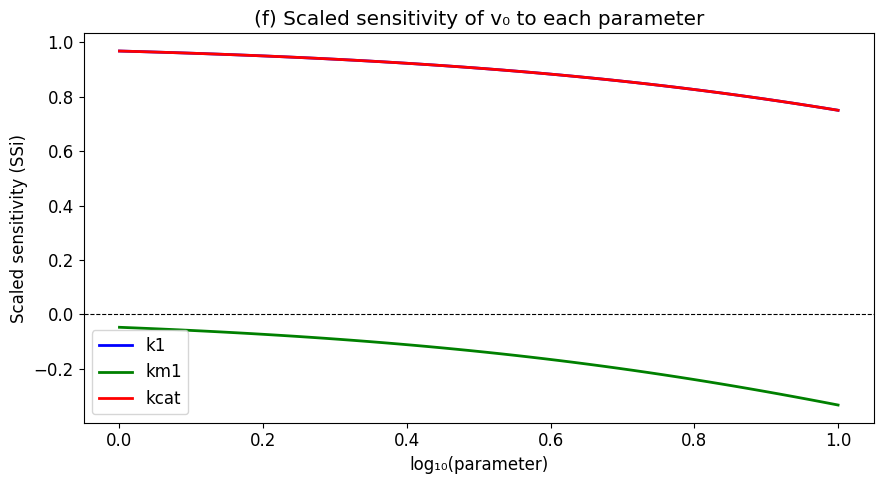

A slope of +1 (or −1) on a log–log sensitivity plot indicates that v₀ scales
linearly with that parameter. The parameter whose |SS| is largest has the most influence.
kcat typically has the highest positive sensitivity (directly sets vmax).
km1 has negative sensitivity (increases KM, reducing v0).
k1 has positive sensitivity (decreases KM, increasing v0).


In [8]:
# Scaled sensitivity: S_p = (p / v0) * (dv0/dp)
# Computed numerically via central differences

def scaled_sensitivity(param_name, param_range, ref_params):
    k1r_, km1r_, kcatr_, E0r_ = ref_params
    sens = []
    for p in param_range:
        eps = p * 1e-5
        if param_name == 'k1':
            v_p = v0(p+eps, km1r_, kcatr_, E0r_)
            v_m = v0(p-eps, km1r_, kcatr_, E0r_)
            v_c = v0(p,     km1r_, kcatr_, E0r_)
        elif param_name == 'km1':
            v_p = v0(k1r_, p+eps, kcatr_, E0r_)
            v_m = v0(k1r_, p-eps, kcatr_, E0r_)
            v_c = v0(k1r_, p,     kcatr_, E0r_)
        elif param_name == 'kcat':
            v_p = v0(k1r_, km1r_, p+eps, E0r_)
            v_m = v0(k1r_, km1r_, p-eps, E0r_)
            v_c = v0(k1r_, km1r_, p,     E0r_)
        dv_dp = (v_p - v_m) / (2*eps)
        sens.append(p / v_c * dv_dp)
    return np.array(sens)

ref = (k1r, km1r, kcatr, E0r)

fig, ax = plt.subplots(figsize=(9, 5))
for name, rng, color in [('k1', k1_range, 'b'), ('km1', km1_range, 'g'), ('kcat', kcat_range, 'r')]:
    ax.plot(np.log10(rng), scaled_sensitivity(name, rng, ref), label=name, color=color, lw=2)

ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('log₁₀(parameter)')
ax.set_ylabel('Scaled sensitivity (SSi)')
ax.set_title('(f) Scaled sensitivity of v₀ to each parameter')
ax.legend()
plt.tight_layout()
plt.savefig('f_sensitivity.png', dpi=150)
plt.show()

print('A slope of +1 (or −1) on a log–log sensitivity plot indicates that v₀ scales')
print('linearly with that parameter. The parameter whose |SS| is largest has the most influence.')
print('kcat typically has the highest positive sensitivity (directly sets vmax).')
print('km1 has negative sensitivity (increases KM, reducing v0).')
print('k1 has positive sensitivity (decreases KM, increasing v0).')

## Parts (g) & (h) – Competing reaction: enzyme produces P and P'

New mechanism:
$$S + E \underset{k_{-1}}{\overset{k_1}{\rightleftharpoons}} ES \xrightarrow{k_{cat1}} P + E$$
$$ES \xrightarrow{k_{cat2}} P' + E$$

Mass balances:
$$\frac{d[S]}{dt}  = -k_1[S][E] + k_{-1}[ES]$$
$$\frac{d[E]}{dt}  = -k_1[S][E] + k_{-1}[ES] + (k_{cat1}+k_{cat2})[ES]$$
$$\frac{d[ES]}{dt} = k_1[S][E] - k_{-1}[ES] - (k_{cat1}+k_{cat2})[ES]$$
$$\frac{d[P]}{dt}  = k_{cat1}[ES]$$
$$\frac{d[P']}{dt} = k_{cat2}[ES]$$

C:\Users\noah2\AppData\Local\Temp\ipykernel_9860\859468757.py:34: RuntimeWarning: invalid value encountered in divide
  sel = np.where(total_prod > 1e-12, P_c / total_prod, np.nan)


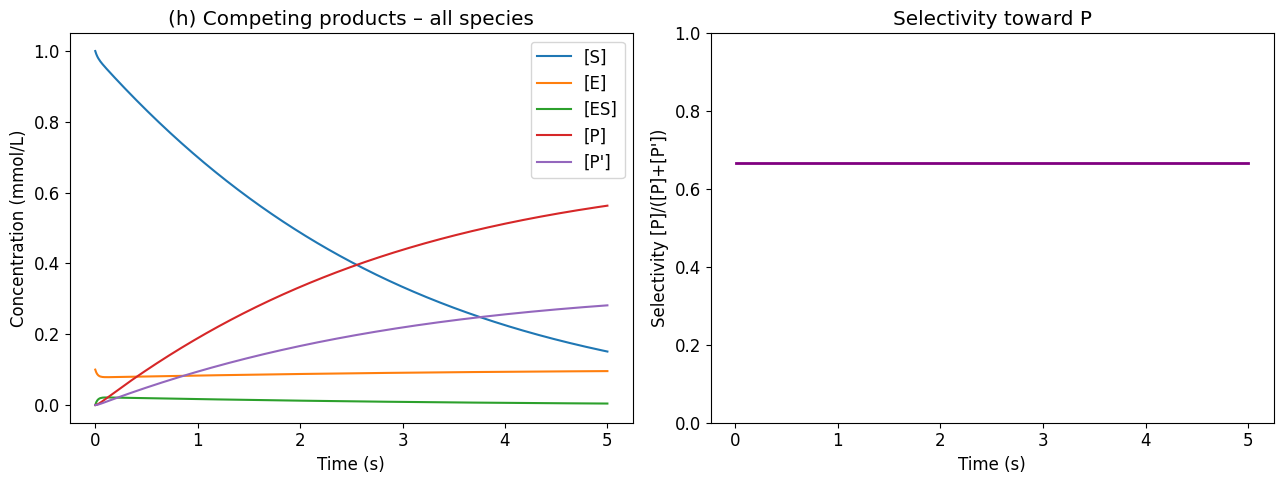

Steady-state selectivity = kcat1/(kcat1+kcat2) = 0.667


In [9]:
# ─── Parameters for competing reaction ───────────────────────────────────────
kcat1 = 10.0   # 1/s   → produces P
kcat2 = 5.0    # 1/s   → produces P'

def ode_competing(t, y, k1, km1, kcat1, kcat2):
    S, E, ES, P, Pp = y
    dS  = -k1*S*E + km1*ES
    dE  = -k1*S*E + km1*ES + (kcat1+kcat2)*ES
    dES =  k1*S*E - km1*ES - (kcat1+kcat2)*ES
    dP  =  kcat1 * ES
    dPp =  kcat2 * ES
    return [dS, dE, dES, dP, dPp]

y0_comp = [S0, E0, ES0, P0, 0.0]
sol_comp = solve_ivp(ode_competing, t_span, y0_comp,
                     args=(k1, km1, kcat1, kcat2),
                     t_eval=t_eval, method='Radau', rtol=1e-8, atol=1e-10)

S_c, E_c, ES_c, P_c, Pp_c = sol_comp.y

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(sol_comp.t, S_c,  label='[S]')
axes[0].plot(sol_comp.t, E_c,  label='[E]')
axes[0].plot(sol_comp.t, ES_c, label='[ES]')
axes[0].plot(sol_comp.t, P_c,  label='[P]')
axes[0].plot(sol_comp.t, Pp_c, label="[P']")
axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('Concentration (mmol/L)')
axes[0].set_title('(h) Competing products – all species')
axes[0].legend()

# Selectivity: P / (P + P')
total_prod = P_c + Pp_c
sel = np.where(total_prod > 1e-12, P_c / total_prod, np.nan)
axes[1].plot(sol_comp.t, sel, color='purple', lw=2)
axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('Selectivity [P]/([P]+[P\'])')
axes[1].set_title('Selectivity toward P')
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.savefig('h_competing.png', dpi=150)
plt.show()

sel_ss = kcat1 / (kcat1 + kcat2)
print(f'Steady-state selectivity = kcat1/(kcat1+kcat2) = {sel_ss:.3f}')

## Part (i) – Improving Selectivity

Both P and P' are formed from the **same intermediate ES**, so selectivity is:
$$\sigma_P = \frac{k_{cat1}}{k_{cat1} + k_{cat2}}$$

This is **independent of k₁, k₋₁, [S], and [E₀]**. The only way to improve selectivity is:

1. **Increase k_cat1** – engineer the enzyme to catalyse the desired reaction faster.
2. **Decrease k_cat2** – engineer the enzyme to suppress the side reaction.

Neither k₁ nor k₋₁ (nor [E₀]) affect selectivity because the ratio P:P' is set entirely by the branching at the ES node.

C:\Users\noah2\AppData\Local\Temp\ipykernel_9860\1125900990.py:10: RuntimeWarning: invalid value encountered in divide
  sel_i = np.where(tot > 1e-12, P_i/tot, np.nan)


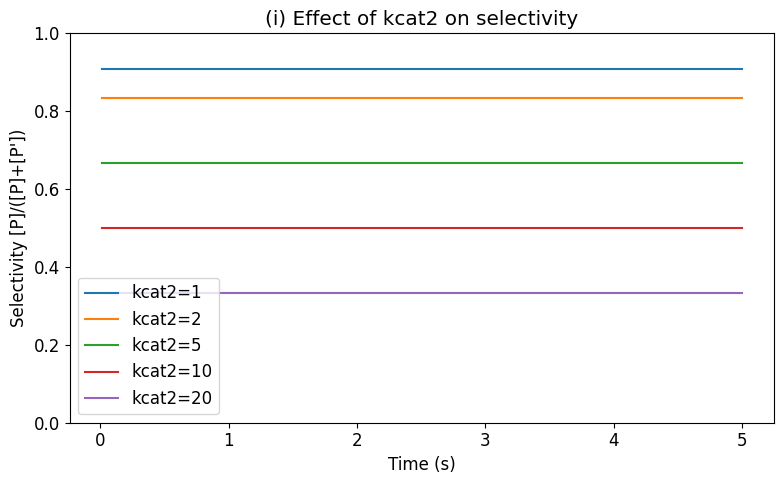

Reducing kcat2 (or increasing kcat1) is the only way to improve selectivity.


In [10]:
# Demonstrate: vary kcat2, fix kcat1=10
kcat2_vals = [1, 2, 5, 10, 20]
fig, ax = plt.subplots()
for kc2 in kcat2_vals:
    sol_i = solve_ivp(ode_competing, t_span, y0_comp,
                      args=(k1, km1, kcat1, kc2),
                      t_eval=t_eval, method='Radau', rtol=1e-8, atol=1e-10)
    P_i, Pp_i = sol_i.y[3], sol_i.y[4]
    tot = P_i + Pp_i
    sel_i = np.where(tot > 1e-12, P_i/tot, np.nan)
    ax.plot(sol_i.t, sel_i, label=f'kcat2={kc2}')

ax.set_xlabel('Time (s)')
ax.set_ylabel('Selectivity [P]/([P]+[P\'])')
ax.set_title('(i) Effect of kcat2 on selectivity')
ax.legend()
ax.set_ylim([0,1])
plt.tight_layout()
plt.savefig('i_selectivity.png', dpi=150)
plt.show()
print('Reducing kcat2 (or increasing kcat1) is the only way to improve selectivity.')